<a href="https://colab.research.google.com/github/shantitamang21/classes/blob/main/Moviereviewsentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

In [ ]:
from nltk.corpus import stopwords

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Movie_Review_Sentiment_Analysis.zip to Movie_Review_Sentiment_Analysis (1).zip


In [ ]:
import os
import pandas as pd

# List the contents of the extracted folder
extract_dir = "extracted_files"
inner_folder = os.path.join(extract_dir, "Movie_Review_Sentiment_Analysis")
print(os.listdir(inner_folder))  # Check exact CSV file name

# Use the correct file path here based on the output
data = pd.read_csv(os.path.join(inner_folder, 'Movie_Review.csv'))

# Show first few rows
print(data.head())

['model.pkl', 'app.py', 'scaler.pkl', 'Movie_Review.csv', 'Movie_review_Model_Creation.ipynb', '.ipynb_checkpoints']
                                                text sentiment
0  My daughter liked it but I was aghast, that a ...       neg
1  I... No words. No words can describe this. I w...       neg
2  this film is basically a poor take on the old ...       neg
3  This is a terrible movie, and I'm not even sur...       neg
4  First of all this movie is a piece of reality ...       pos


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
neg,500
pos,500


In [ ]:
data.dropna(inplace= True)

In [ ]:
def clean_review(review):
    str = ' '.join(word for word in review.split() if word.lower() not in stopwords.words('english'))
    return str

In [ ]:
data['text'] = data['text'].apply(clean_review)

In [ ]:
from wordcloud import WordCloud

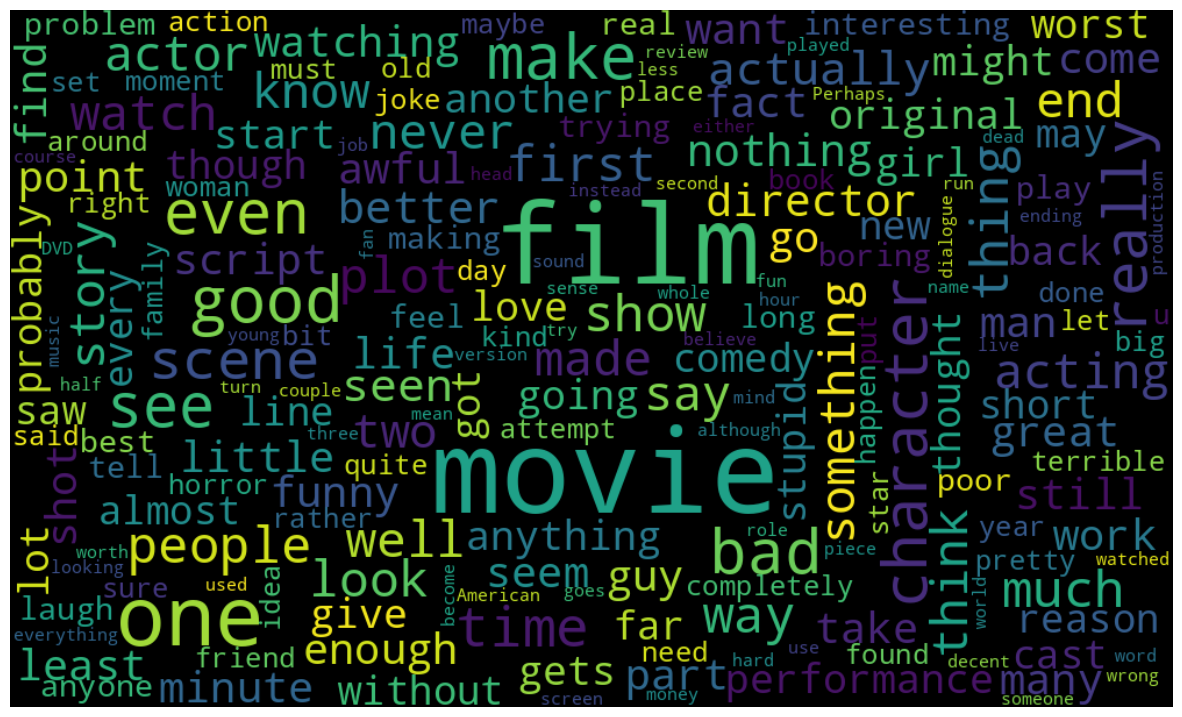

In [ ]:
reviews = ' '.join(word for word in data['text'][data['sentiment'] == 'neg'].astype(str))

wordcloud = WordCloud(height=600, width=1000, max_font_size=100)

plt.figure(figsize=(15, 12))
plt.imshow(wordcloud.generate(reviews), interpolation='bilinear')
plt.axis('off')
plt.show()

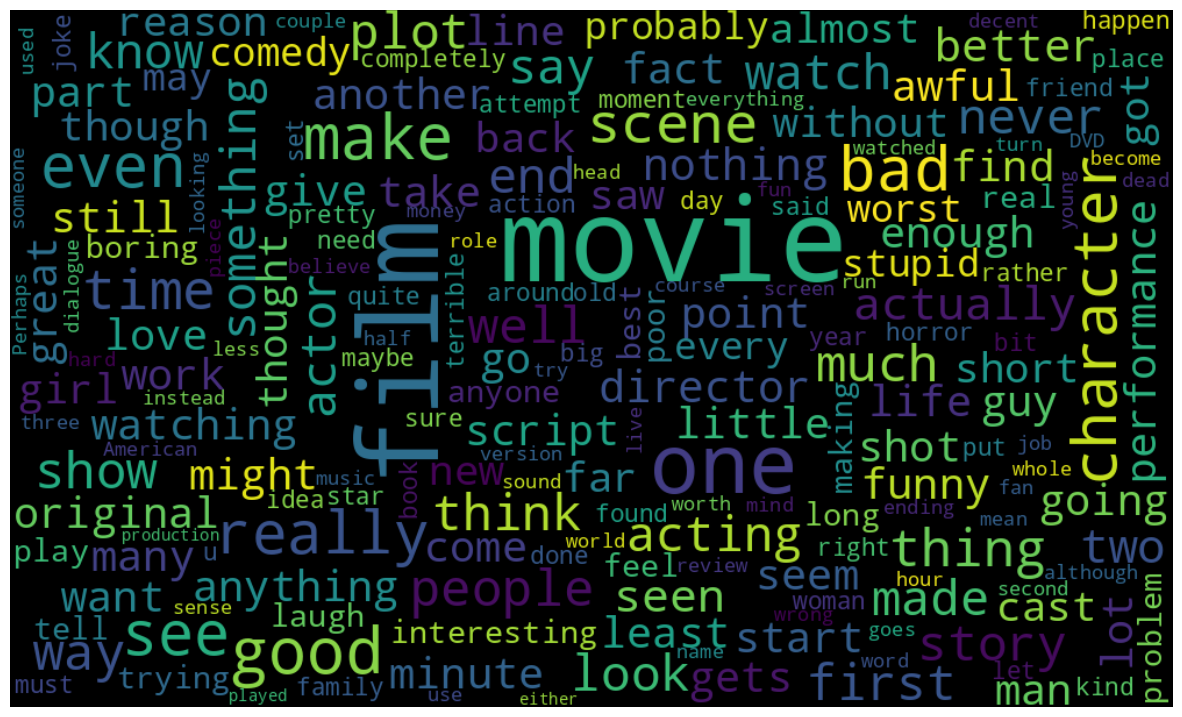

In [ ]:
reviews = ' '.join(word for word in data['text'][data['sentiment'] == 'neg'].astype(str))

wordcloud = WordCloud(height=600, width=1000, max_font_size=100)

plt.figure(figsize=(15, 12))
plt.imshow(wordcloud.generate(reviews), interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(max_features=2500)

In [ ]:
reviews = cv.fit_transform(data['text']).toarray()

In [ ]:
data['sentiment'] = data['sentiment'].replace(['pos', 'neg'], [1, 0])

<ipython-input-25-59a17798b8ce>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sentiment'] = data['sentiment'].replace(['pos', 'neg'], [1, 0])


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
0,500
1,500


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
reviews_train, reviews_test, sent_train, sent_test = train_test_split(reviews, data['sentiment'], test_size=0.2)

In [ ]:
model.fit(reviews_train, sent_train)

LogisticRegression()

In [ ]:
predict = model.predict(reviews_test)

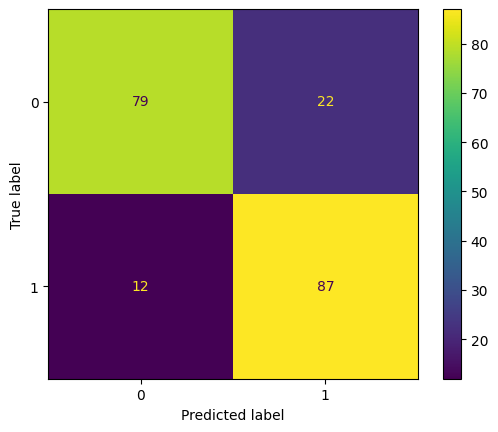

In [ ]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(sent_test, predict, labels=model.classes_)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
display.plot()
plt.show()

In [ ]:
import pickle as pk

In [ ]:
pk.dump(model, open('model.pkl', 'wb'))

In [ ]:
from google.colab import files


with open('Moviereviewsentimentanalysis.ipynb', 'w') as f:
    f.write("This is a sample file.")

# Download it to your computer
files.download('Moviereviewsentimentanalysis.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>